In [5]:
# plotting_02 contains condition of some of the selected participants (SNR >= 1) before and after workload

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


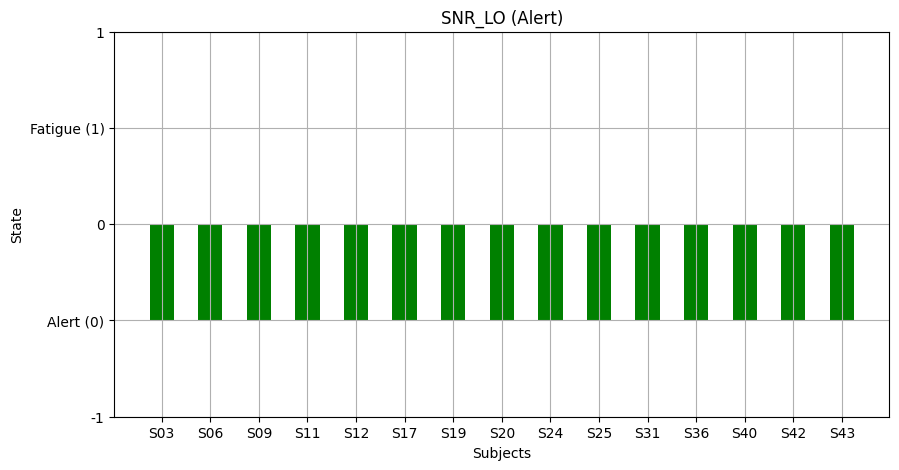

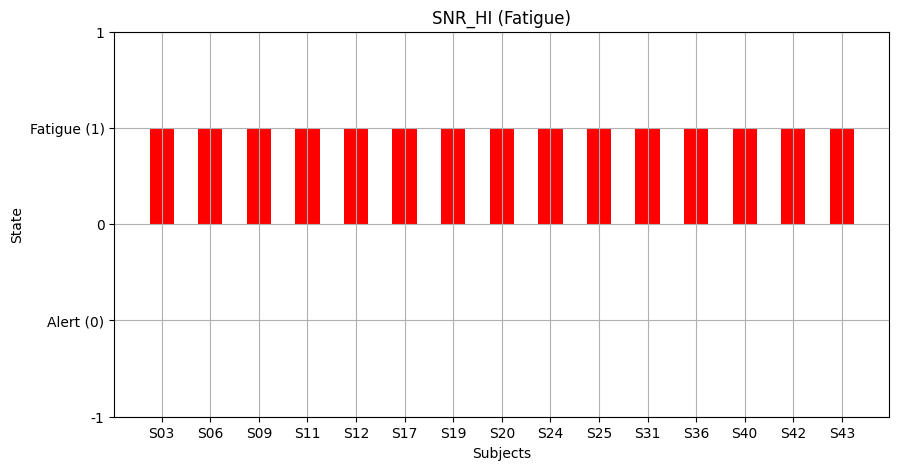

In [2]:
# =========================
# 1. IMPORTS
# =========================
import os
import re
import matplotlib.pyplot as plt

# =========================
# 2. SET YOUR PATHS
# =========================
hi_folder = "/content/drive/MyDrive/SNR_HI"
lo_folder = "/content/drive/MyDrive/SNR_LO"

# =========================
# 3. EXTRACT SUBJECT ID
# =========================
def extract_subject(filename):
    match = re.search(r"[Ss]\d{2}", filename)
    return match.group().upper() if match else None

# =========================
# 4. GET SUBJECT LIST
# =========================
def get_subjects(folder):
    subjects = set()

    for file in os.listdir(folder):
        if file.endswith(".csv"):
            sub = extract_subject(file)
            if sub:
                subjects.add(sub)

    return sorted(subjects, key=lambda x: int(x[1:]))

# =========================
# 5. PLOT FUNCTION
# =========================
def plot_state(subjects, y_value, color, title):
    x = list(range(len(subjects)))
    y = [y_value] * len(subjects)

    plt.figure(figsize=(10, 5))
    plt.bar(x, y, color=color, width=0.5)

    plt.xticks(x, subjects)

    # Custom y-axis labels for clarity
    plt.yticks(
        [-1, -0.5, 0, 0.5, 1],
        [-1, "Alert (0)", 0, "Fatigue (1)", 1]
    )

    plt.ylim(-1, 1)

    plt.xlabel("Subjects")
    plt.ylabel("State")
    plt.title(title)

    plt.grid(True)
    plt.show()

# =========================
# 6. LO → ALERT (-0.5)
# =========================
subjects_lo = get_subjects(lo_folder)

plot_state(
    subjects_lo,
    y_value=-0.5,   # important fix
    color="green",
    title="SNR_LO (Alert)"
)

# =========================
# 7. HI → FATIGUE (+0.5)
# =========================
subjects_hi = get_subjects(hi_folder)

plot_state(
    subjects_hi,
    y_value=0.5,    # important fix
    color="red",
    title="SNR_HI (Fatigue)"
)